In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import scipy as sp
from skimage import io
from skimage.color import rgb2hsv, hsv2rgb

gamma = 2.2
Z_min = 0.02
Z_max = 0.95
t = 1/2048


Npictures = 5

t_list = np.array([t*2**k for k in range(Npictures)])

!pip install OpenEXR
!pip install Imath
!apt-get install -y python3-imath

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
python3-imath is already the newest version (3.1.4-3).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


In [ ]:
from cp_hw2 import read_colorchecker_gm


ModuleNotFoundError: No module named 'cp_hw2'

In [ ]:
read_colorchecker_gm()

In [4]:
im_list = [io.imread(f'data/door_stack/exposure{i}.tiff').astype(np.float32)/65535 for i in range(1,Npictures + 1)]

In [5]:
im = im_list[-1]

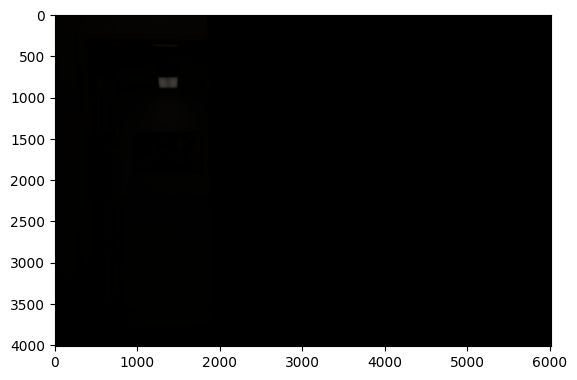

In [6]:
plt.imshow(im_list[-1])

In [7]:
def w_uniform(z, tk=1):
  return np.logical_and(Z_min <= z, z<= Z_max)

def w_tent(z, tk=1):
  w = np.minimum(z, np.ones_like(z) - z)
  return w * w_uniform(z)

def w_Gaussian(z, tk=1):
  w = np.exp(-16 * (z - 0.5) ** 2)
  return w * w_uniform(z)

def w_photon(z, tk):
  return tk * w_uniform(z)

valid_w = ['uniform', 'tent', 'Gaussian', 'photon']
def w(z, w_type='uniform', tk=1):
  if w_type == 'uniform':
    return w_uniform(z, tk)
  elif w_type == 'tent':
    return w_tent(z, tk)
  elif w_type == 'Gaussian':
    return w_Gaussian(z, tk)
  elif w_type == 'photon':
    return w_photon(z, tk)
  else:
    raise ValueError('Invalid weight function')


def HDR_stack(im_list, t_list, w_type='uniform'):
  assert(len(im_list) == len(t_list))
  Npictures = len(im_list)

  sum_nominator = np.zeros_like(im_list[0])
  sum_denominator = np.ones_like(sum_nominator) * 0.001

  for i in range(Npictures):
    w_array = w(im_list[i], w_type, t_list[i])
    sum_nominator += w_array * im_list[i] / (t_list[i])
    sum_denominator += w_array

  return sum_nominator / sum_denominator

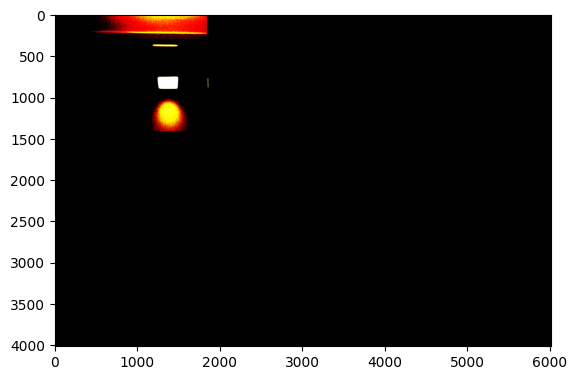

In [8]:
for i in range(4):
  final_picture = HDR_stack(im_list, t_list, valid_w[i])
  plt.imshow(final_picture ** (1/gamma))

  cv2.imwrite(f'output_{valid_w[i]}.HDR', final_picture[:, :, ::-1].astype(np.float32))



In [9]:
final_pictures = [HDR_stack(im_list, t_list, w) for w in valid_w]


(580.0, 1550.0)

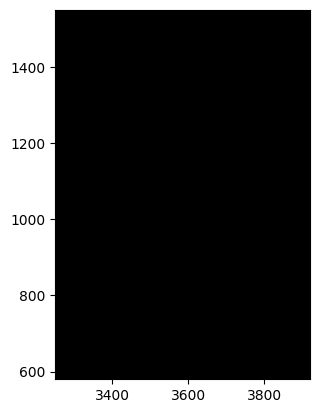

In [10]:
plt.imshow(np.abs(10 * final_pictures[0] ** (1/2)))
plt.xlim(3250,3920)
plt.ylim(580,1550)

Question 2 Color correction and white balancing (20 points)

In [11]:
from matplotlib.ticker import MultipleLocator

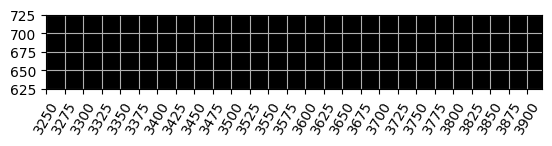

In [12]:
plt.imshow(np.abs(10 * final_pictures[0] ** (1/2)))
plt.xlim(3250,3920)
plt.ylim(625,725)
plt.grid()

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(25))
ax.yaxis.set_major_locator(MultipleLocator(25))
ax.tick_params(axis="x", labelrotation=60)  # try 30/60 if you prefer

In [13]:
# format: (xlow, xhigh, ylow, yhigh)
coords = [
    # First row from the top
    (3300, 3400, 1400, 1500),
    (3470, 3575, 1400, 1500),
    (3625, 3725, 1400, 1500),
    (3775, 3900, 1400, 1500),
    # second
    (3300, 3400, 1250, 1350),
    (3470, 3575, 1250, 1350),
    (3625, 3725, 1250, 1350),
    (3775, 3875, 1250, 1350),
    # third
    (3275, 3400, 1100, 1200),
    (3450, 3575, 1100, 1200),
    (3625, 3725, 1100, 1200),
    (3775, 3875, 1100, 1200),
    # fourth
    (3300, 3400, 950, 1050),
    (3450, 3550, 950, 1050),
    (3600, 3700, 950, 1050),
    (3775, 3875, 950, 1050),
    # fifth
    (3300, 3400, 775, 885),
    (3450, 3550, 775, 885),
    (3600, 3700, 775, 885),
    (3775, 3875, 775, 885),
    # sixth
    (3300, 3400, 625, 725),
    (3450, 3550, 625, 725),
    (3600, 3700, 625, 725),
    (3750, 3850, 625, 725),
]

measured_rgb_values = []
for coord in coords:
  measured_rgb = np.mean(final_pictures[0][coord[2]:coord[3], coord[0]:coord[1]], axis=(0,1))
  #measured_rgb = np.append(measured_rgb, 1)
  measured_rgb_values.append(measured_rgb)

measured_rgb_values = np.array(measured_rgb_values)
measured_rgb_values

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]], dtype=float32)

In [14]:
true_rgb_values = read_colorchecker_gm()
true_rgb_values = np.array(true_rgb_values).transpose(1, 2, 0).reshape(-1, 3, order='F')

NameError: name 'read_colorchecker_gm' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# make a 4x6 grid of color squares
swatch = measured_rgb_values.reshape(4,6,3) * 70

#plt.figure(figsize=(24, 1))
plt.imshow(swatch, interpolation="nearest")
plt.axis("off")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# make a 4x6 grid of color squares
swatch = true_rgb_values.reshape(4,6,3)

#plt.figure(figsize=(24, 1))
plt.imshow(swatch, interpolation="nearest")
plt.axis("off")
plt.show()


In [ ]:
from scipy.optimize import curve_fit

In [ ]:
measured_rgb_values

In [ ]:
def fit_affine_3d(X, Y):
    """
    Fit y ≈ A x + t (A: 3x3, t: 3,) in least squares sense.
    Returns A, t, rmse
    """
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    assert X.shape == Y.shape and X.shape[1] == 3

    # Build augmented design matrix [x y z 1]
    X_aug = np.hstack([X, np.ones((X.shape[0], 1))])   # (N,4)

    # Solve X_aug @ M ≈ Y  where M is (4,3)
    M, residuals, rank, s = np.linalg.lstsq(X_aug, Y, rcond=None)

    A = M[:3, :].T          # (3,3)
    t = M[3, :]             # (3,)

    Y_hat = X @ A.T + t
    rmse = np.sqrt(np.mean(np.sum((Y - Y_hat)**2, axis=1)))
    return A, t, rmse

In [ ]:
A, t, _ = fit_affine_3d(measured_rgb_values, true_rgb_values)

In [ ]:
tonemapped = (np.einsum('...i,ji->...j', final_picture, A) + t)

In [ ]:
plt.imshow(((tonemapped) / 10) ** (1/2))